In [10]:
import glob
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# pandas の表示省略を無効化（必要なら値を調整）
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

units = [64, 128, 256]
base_path = "/work/robomimic/csv/result/error/proposal/2bit/gaussian"
TOP_K = 10  # 上位k行で平均

def extract_gaussian(path):
    m = re.search(r"gaussian([0-9.]+)\.csv", path)
    return float(m.group(1)) if m else None

results = []

for unit in units:
    pattern = f"{base_path}/unit{unit}/gaussian*.csv"
    files = sorted(glob.glob(pattern))

    for f in files:
        g = extract_gaussian(f)
        if g is None:
            continue

        df = pd.read_csv(f)

        # === ここが変更点 ===
        # 行そのものから success_rate 上位kを選択
        topk = df.nlargest(TOP_K, "success_rate")
        mean_success = topk["success_rate"].mean()
        std_success = topk["success_rate"].std()

        results.append({
            "unit": unit,
            "gaussian": g,
            "mean_success": mean_success,
            "std_success": std_success
        })

results_df = pd.DataFrame(results)
display(results_df)


,unit,gaussian,mean_success,std_success
0,64,0.00,0.963,0.014181
1,64,0.01,0.932,0.032931
2,64,0.02,0.899,0.042282
3,64,0.03,0.832,0.068443
4,64,0.04,0.765,0.100028
5,64,0.05,0.630,0.122927
6,64,0.06,0.522,0.146652
7,64,0.07,0.358,0.193552
8,64,0.08,0.261,0.202454
9,64,0.09,0.168,0.218368


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
custom_colors = { "ncp_u64_best": "#351fb4", "u64": "#351fb4", "ncp_u128_best": "#06a600", "u128": "#06a600", "ncp_u256_best": "#d62728", "u256": "#d62728", } 
markers = { "ncp_u64_best": "s", "u64": "s", "ncp_u128_best": "o", "u128": "o", "ncp_u256_best": "^", "u256": "^", }
sns.set_style("white")

# ===== フォントサイズ設定 =====
TICK_SIZE = 25
LABEL_SIZE = 28
LEGEND_SIZE = 22

plt.figure(figsize=(8, 5))

for unit, color, marker in zip(
    units,
    [custom_colors["u64"], custom_colors["u128"], custom_colors["u256"]],
    [markers["u64"], markers["u128"], markers["u256"]],
):
    # results_df から直接取得
    df_u = results_df[results_df["unit"] == unit].sort_values("gaussian")

    # gaussian = 0.0 を強調
    if 0.0 in df_u["gaussian"].values:
        y0 = df_u.loc[df_u["gaussian"] == 0.0, "mean_success"].values[0]
        plt.scatter(
            [0.0], [y0 * 100],
            marker=marker,
            s=120,
            facecolors="white",
            edgecolors=color,
            linewidths=3,
            zorder=6,
        )

    # 折れ線
    plt.plot(
        df_u["gaussian"],
        df_u["mean_success"] * 100,
        color=color,
        linewidth=3,
        zorder=3,
        label=f"u{unit}",
    )

    # マーカー
    plt.scatter(
        df_u["gaussian"],
        df_u["mean_success"] * 100,
        marker=marker,
        s=180,
        facecolors="white",
        edgecolors=color,
        linewidths=3,
        zorder=5,
    )

    # ===== エラーバー =====
    plt.errorbar(
        df_u["gaussian"],
        df_u["mean_success"] * 100,
        yerr=df_u["std_success"] * 100,
        fmt="none",          # マーカーは描かない
        ecolor=color,
        elinewidth=2.5,
        capsize=6,
        capthick=2.5,
        zorder=3,
        alpha=0.8,
    )

# ===== 軸設定 =====
plt.ylim(0, 105)
plt.xlim(-0.005, 0.105)

plt.xticks(
    np.arange(0.0, 0.11, 0.02),
    fontsize=TICK_SIZE,
    fontweight="bold",
)
plt.yticks(
    np.arange(0, 101, 20),
    fontsize=TICK_SIZE,
    fontweight="bold",
)

# ===== グリッド =====
ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.02))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.01))

ax.grid(which="major", linestyle="--", linewidth=1.0)
ax.grid(which="minor", linestyle="--", linewidth=0.8)

# ===== 枠線 =====
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

plt.tight_layout()
plt.show()


KeyError: 'unit'

<Figure size 800x500 with 0 Axes>

In [ ]:
import io
import re
import glob
import pandas as pd

def load_eval_csv(src):
    """
    src:
      - パス(str)
      - CSVテキスト(str, 先頭が 'name,' 等)
    """
    if isinstance(src, str):
        s = src.lstrip()
        if "\n" in s and (s.startswith("name,") or s.startswith("name,")):
            return pd.read_csv(io.StringIO(src))
    return pd.read_csv(src)

def normalize_eval_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]

    # success_rate 列を確実に用意
    if "success_rate" not in df.columns:
        for cand in ["success", "successRate", "success_rate_mean", "mean_success"]:
            if cand in df.columns:
                df["success_rate"] = df[cand]
                break
    if "success_rate" not in df.columns:
        raise KeyError(f"success_rate column not found. columns={list(df.columns)}")

    df["success_rate"] = pd.to_numeric(df["success_rate"], errors="coerce")
    df = df.dropna(subset=["success_rate"])

    # name が無い場合でも落とさない
    if "name" in df.columns:
        df["name"] = df["name"].astype(str)
        df["seed"] = pd.to_numeric(df["name"].str.extract(r"seed(\d+)", expand=False), errors="coerce")
    else:
        df["seed"] = pd.NA

    return df

def summarize_topk_from_files(base_path: str, units, file_glob: str, param_regex: str, param_name: str, top_k: int = 10):
    """
    base_path/unit{unit}/ 以下のCSVを集計して
    unit, param_name(=gaussian/shift), mean_success, std_success を返す
    """
    results = []
    for unit in units:
        pattern = f"{base_path}/unit{unit}/{file_glob}"
        files = sorted(glob.glob(pattern))
        for f in files:
            m = re.search(param_regex, f)
            if not m:
                continue
            param_val = float(m.group(1))

            df = normalize_eval_df(load_eval_csv(f))

            # 上位k行の平均・標準偏差
            topk = df.nlargest(top_k, "success_rate")
            results.append({
                "unit": unit,
                param_name: param_val,
                "mean_success": float(topk["success_rate"].mean()),
                "std_success": float(topk["success_rate"].std(ddof=1)) if len(topk) > 1 else 0.0,
                "n_rows": int(len(df)),
                "n_topk": int(len(topk)),
            })

    return pd.DataFrame(results)

# ===== 例: gaussian =====
units = [64, 128, 256]
TOP_K = 10

base_path_gauss = "/work/robomimic/csv/result/error/proposal/2bit/gaussian"
results_df_gauss = summarize_topk_from_files(
    base_path=base_path_gauss,
    units=units,
    file_glob="gaussian*.csv",
    param_regex=r"gaussian([0-9.]+)\.csv$",
    param_name="gaussian",
    top_k=TOP_K,
).sort_values(["unit", "gaussian"])

display(results_df_gauss)

# ===== 例: shift =====
base_path_shift = "/work/robomimic/csv/result/error/proposal/2bit/shift"
results_df_shift = summarize_topk_from_files(
    base_path=base_path_shift,
    units=units,
    file_glob="shift*.csv",
    param_regex=r"shift([0-9.]+)\.csv$",
    param_name="shift",
    top_k=TOP_K,
).sort_values(["unit", "shift"])

display(results_df_shift)

,unit,gaussian,mean_success,std_success,n_rows,n_topk
0,64,0.00,0.963,0.014181,20,10
1,64,0.01,0.932,0.032931,20,10
2,64,0.02,0.899,0.042282,20,10
3,64,0.03,0.832,0.068443,20,10
4,64,0.04,0.765,0.100028,20,10
5,64,0.05,0.630,0.122927,20,10
6,64,0.06,0.522,0.146652,20,10
7,64,0.07,0.358,0.193552,20,10
8,64,0.08,0.261,0.202454,20,10
9,64,0.09,0.168,0.218368,20,10


,unit,shift,mean_success,std_success,n_rows,n_topk
0,64,0.00,0.963,0.014181,20,10
1,64,0.01,0.964,0.025473,20,10
2,64,0.02,0.957,0.024518,20,10
3,64,0.03,0.956,0.023664,20,10
4,64,0.04,0.935,0.027183,20,10
5,64,0.05,0.936,0.026331,20,10
6,64,0.06,0.923,0.034657,20,10
7,64,0.07,0.905,0.032059,20,10
8,64,0.08,0.900,0.040277,20,10
9,64,0.09,0.872,0.055538,20,10


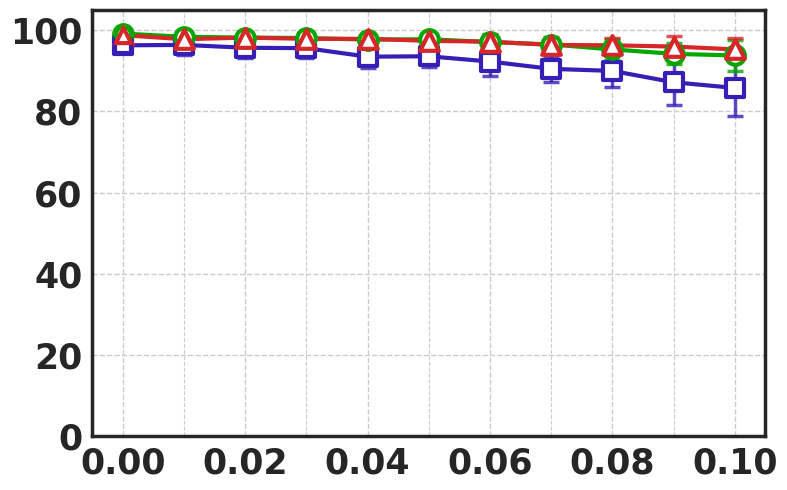

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
custom_colors = { "ncp_u64_best": "#351fb4", "u64": "#351fb4", "ncp_u128_best": "#06a600", "u128": "#06a600", "ncp_u256_best": "#d62728", "u256": "#d62728", } 
markers = { "ncp_u64_best": "s", "u64": "s", "ncp_u128_best": "o", "u128": "o", "ncp_u256_best": "^", "u256": "^", }
sns.set_style("white")

# ===== フォントサイズ設定 =====
TICK_SIZE = 25
LABEL_SIZE = 28
LEGEND_SIZE = 22

plt.figure(figsize=(8, 5))

for unit, color, marker in zip(
    units,
    [custom_colors["u64"], custom_colors["u128"], custom_colors["u256"]],
    [markers["u64"], markers["u128"], markers["u256"]],
):
    # results_df から直接取得
    df_u = results_df_shift[results_df_shift["unit"] == unit].sort_values("shift")

    # gaussian = 0.0 を強調
    if 0.0 in df_u["shift"].values:
        y0 = df_u.loc[df_u["shift"] == 0.0, "mean_success"].values[0]
        plt.scatter(
            [0.0], [y0 * 100],
            marker=marker,
            s=120,
            facecolors="white",
            edgecolors=color,
            linewidths=3,
            zorder=6,
        )

    # 折れ線
    plt.plot(
        df_u["shift"],
        df_u["mean_success"] * 100,
        color=color,
        linewidth=3,
        zorder=3,
        label=f"u{unit}",
    )

    # マーカー
    plt.scatter(
        df_u["shift"],
        df_u["mean_success"] * 100,
        marker=marker,
        s=180,
        facecolors="white",
        edgecolors=color,
        linewidths=3,
        zorder=5,
    )

    # ===== エラーバー =====
    plt.errorbar(
        df_u["shift"],
        df_u["mean_success"] * 100,
        yerr=df_u["std_success"] * 100,
        fmt="none",          # マーカーは描かない
        ecolor=color,
        elinewidth=2.5,
        capsize=6,
        capthick=2.5,
        zorder=3,
        alpha=0.8
    )

# ===== 軸設定 =====
plt.ylim(0, 105)
plt.xlim(-0.005, 0.105)

plt.xticks(
    np.arange(0.0, 0.11, 0.02),
    fontsize=TICK_SIZE,
    fontweight="bold",
)
plt.yticks(
    np.arange(0, 101, 20),
    fontsize=TICK_SIZE,
    fontweight="bold",
)

# ===== グリッド =====
ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.02))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.01))

ax.grid(which="major", linestyle="--", linewidth=1.0)
ax.grid(which="minor", linestyle="--", linewidth=0.8)

# ===== 枠線 =====
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

plt.tight_layout()
plt.show()
